# HVAC Hybrid Model

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

import seaborn as sns 
import matplotlib.pyplot as plt

np.random.seed(42)

In [2]:
hvac_data = pd.read_csv('hvac_model_zones.csv')

In [3]:
hvac_data.columns = hvac_data.columns.str.replace(r"^b'|'$|\[.*?\]", "", regex=True)

In [4]:
hvac_data = hvac_data.loc[hvac_data['Environment:Site Day Type Index'] != 0]
hvac_data["HVAC_kWh"] = hvac_data["Electricity:HVAC"] * 2.77778e-7
hvac_data.drop(columns='Electricity:HVAC', axis=1, inplace=True)

In [5]:
occupant_cols = [col for col in hvac_data.columns if 'Occupant' in col]
# hvac_data["TotalOccCount"] = hvac_data[occupant_cols].sum(axis=1)
hvac_data.drop(columns=occupant_cols, axis=1, inplace=True)

In [6]:
# time_shifts = [0.5, 1]

# for h in time_shifts:
#     steps = int(h * 6)
#     hvac_data[f"Occ_minus{int(h*60)}"] = hvac_data["TotalOccCount"].shift(steps)

# for h in time_shifts:
#     steps = int(h * 6)
#     hvac_data[f"Occ_plus{int(h*60)}"] = hvac_data["TotalOccCount"].shift(-steps)

In [7]:
lenOfData = len(hvac_data)
hvac_data.index = pd.date_range(start="2004-01-01 00:00:00", periods=lenOfData, freq="10min")

In [8]:
def add_lags(df):
    for col in df.columns:
        target_map = df[col].to_dict()
        df[f'{col}_lag1'] = (df.index - pd.Timedelta('7 days')).map(target_map)
        df[f'{col}_lag2'] = (df.index - pd.Timedelta('14 days')).map(target_map)
        df[f'{col}_lag3'] = (df.index - pd.Timedelta('21 days')).map(target_map)
    return df

hvac_data = add_lags(hvac_data)

In [9]:
def create_features(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df

hvac_data = create_features(hvac_data)

In [10]:
features = [col for col in hvac_data.columns if '_lag' in col]
features += ['hour', 'dayofweek', 'month', 'year', 'dayofmonth', 'weekofyear']
target = 'HVAC_kWh'

In [11]:
hvac_data = hvac_data[features+[target]]

In [12]:
x_train, y_train = hvac_data[features][hvac_data.index.month < 10], hvac_data[target][hvac_data.index.month < 10]
x_val, y_val = hvac_data[features][(hvac_data.index.month >= 10) & (hvac_data.index.month <= 11)], hvac_data[target][(hvac_data.index.month >= 10) & ((hvac_data.index.month <= 11))]
x_test, y_test = hvac_data[features][(hvac_data.index.month > 11) & (hvac_data.index.month <= 12)], hvac_data[target][(hvac_data.index.month > 11) & ((hvac_data.index.month <= 12))]

In [13]:
x_train.index.max()

Timestamp('2004-09-30 23:50:00')

In [14]:
x_val.index.min()

Timestamp('2004-10-01 00:00:00')

In [15]:
x_val.index.max()

Timestamp('2004-11-30 23:50:00')

In [16]:
x_test.index.min()

Timestamp('2004-12-01 00:00:00')

In [17]:
def compute_metrics(test_data,forecast_mean):
    mae = mean_absolute_error(test_data, forecast_mean)
    mse = mean_squared_error(test_data, forecast_mean)
    rmse = np.sqrt(mse)


    metrics = {
        "mae":mae,
        "mse":mse,
        "rmse":rmse
    }

    return metrics

### Hybrid with Lags

In [18]:
features = [col for col in hvac_data.columns if col not in ['HVAC_kWh']]
target = 'HVAC_kWh'

In [19]:
x_train = x_train.bfill()

In [20]:
#define and train linear regression model
lin_reg_hybrid_lags = LinearRegression()
lin_reg_hybrid_lags.fit(x_train[features], y_train)

#Make predictions on train set and prepare data for XGBoost Model
y_train_residuals_hybrid_lags = y_train - pd.Series(lin_reg_hybrid_lags.predict(x_train[features]), index=x_train.index)
y_train_hybrid_lags = y_train_residuals_hybrid_lags
xgb_reg_hybrid_lags = xgb.XGBRegressor(base_score=0.5,
                      booster='gbtree',
                      n_estimators=200,
                      objective='reg:squarederror',
                      max_depth=5,
                      learning_rate=0.05)
xgb_reg_hybrid_lags.fit(x_train[features], y_train_hybrid_lags,
       # eval_set=[(x_train, y_train)],
       verbose=100)

x_test = x_test.ffill()

y_pred_lin_reg_lags = lin_reg_hybrid_lags.predict(x_val[features])
y_pred_xgb_reg_lags = xgb_reg_hybrid_lags.predict(x_val[features])

y_pred_combined_lags = y_pred_lin_reg_lags + y_pred_xgb_reg_lags
y_pred_combined_lags = pd.Series(y_pred_combined_lags, index = x_val.index)

In [21]:
pred_df_hybrid_lags = hvac_data[(hvac_data.index.month >= 10) & (hvac_data.index.month <= 10)]

In [22]:
pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags

/var/folders/9p/w309j4n94633ymfb_v3x990r0000gn/T/ipykernel_95418/243560393.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags


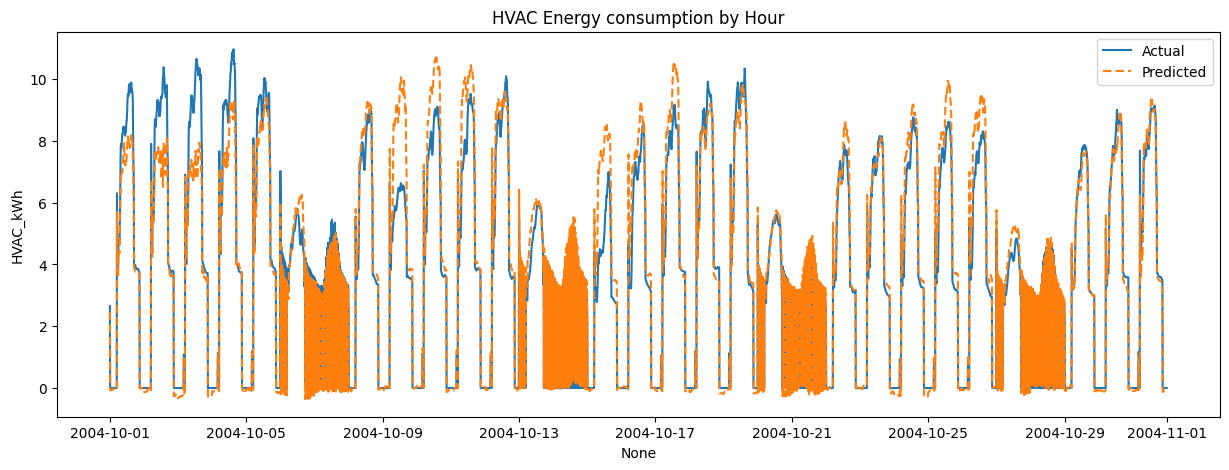

In [ ]:
plt.figure(figsize=(15, 5))
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['HVAC_kWh'], label='Actual')
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['Predictions'], label='Predicted', dashes=(4,2))
plt.title('HVAC Energy consumption by Hour')
plt.legend()
plt.show()

compute_metrics(pred_df_hybrid_lags['HVAC_kWh'], pred_df_hybrid_lags['Predictions'])

### Extract top 15 features from Hybrid with Lags model

In [25]:
xgb_importance = pd.Series(xgb_reg_hybrid_lags.feature_importances_, index=x_train.columns)
xgb_importance_sorted = xgb_importance.sort_values(ascending=False)

top_15_features = xgb_importance_sorted[:15].index.tolist()

In [26]:
#define and train linear regression model
lin_reg_hybrid_lags = LinearRegression()
lin_reg_hybrid_lags.fit(x_train[top_15_features], y_train)

#Make predictions on train set and prepare data for XGBoost Model
y_train_residuals_hybrid_lags = y_train - pd.Series(lin_reg_hybrid_lags.predict(x_train[top_15_features]), index=x_train.index)

y_train_hybrid_lags = y_train_residuals_hybrid_lags
xgb_reg_hybrid_lags = xgb.XGBRegressor(base_score=0.5,
                      booster='gbtree',
                      n_estimators=200,
                      objective='reg:squarederror',
                      max_depth=5,
                      learning_rate=0.05)
xgb_reg_hybrid_lags.fit(x_train[top_15_features], y_train_hybrid_lags,
       # eval_set=[(x_train, y_train)],
       verbose=100)

y_pred_lin_reg_lags = lin_reg_hybrid_lags.predict(x_val[top_15_features])
y_pred_xgb_reg_lags = xgb_reg_hybrid_lags.predict(x_val[top_15_features])

y_pred_combined_lags = y_pred_lin_reg_lags + y_pred_xgb_reg_lags
y_pred_combined_lags = pd.Series(y_pred_combined_lags, index = x_val.index)

/var/folders/9p/w309j4n94633ymfb_v3x990r0000gn/T/ipykernel_95418/3065555433.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags


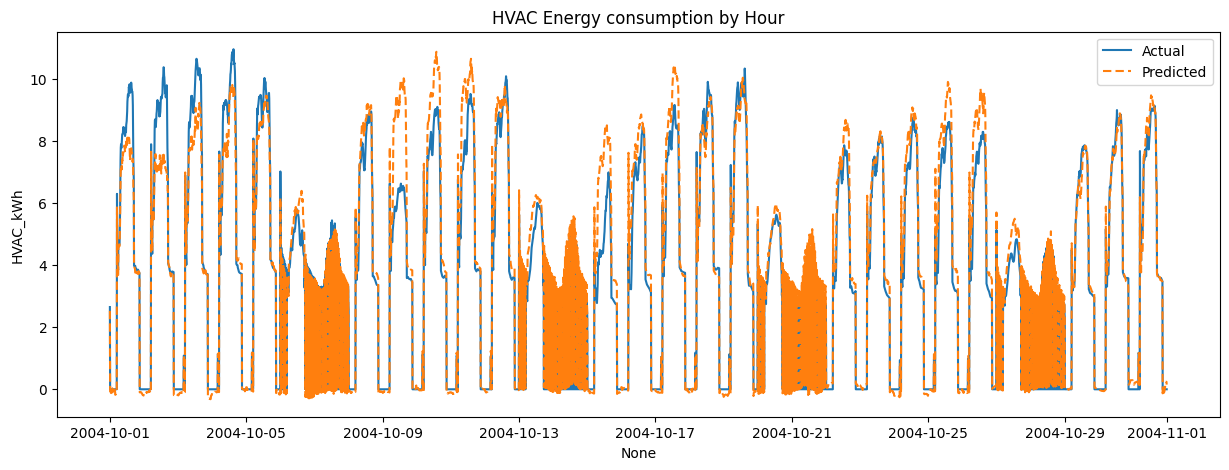

{'mae': 0.4767930900858572,
 'mse': 0.6045590986354608,
 'rmse': 0.7775339855179713}

In [27]:
pred_df_hybrid_lags = hvac_data[(hvac_data.index.month >= 10) & (hvac_data.index.month <= 10)]
pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags
plt.figure(figsize=(15, 5))
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['HVAC_kWh'], label='Actual')
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['Predictions'], label='Predicted', dashes=(4,2))
plt.title('HVAC Energy consumption by Hour')
plt.legend()
plt.show()
compute_metrics(pred_df_hybrid_lags['HVAC_kWh'], pred_df_hybrid_lags['Predictions'])

Forcasting the future

In [28]:
future = pd.date_range(x_test.index.min(),x_test.index.max(), freq='10 min')

In [29]:
# future = pd.date_range('2004-11-01','2004-12-31', freq='10 min')
future_df = pd.DataFrame(index=future)
future_df['isFuture'] = True
x_val['isFuture'] = False
df_and_future = pd.concat([x_val, future_df])

In [31]:
def add_lags_test(df):
    for col in x_train.columns:
        target_map = df[col].to_dict()
        df[f'{col}'] = (df.index - pd.Timedelta('7 days')).map(target_map)
        df[f'{col}'] = (df.index - pd.Timedelta('14 days')).map(target_map)
        df[f'{col}'] = (df.index - pd.Timedelta('21 days')).map(target_map)
    return df

df_and_future = add_lags_test(df_and_future)

In [32]:
def create_features_test(df):
    """
    Create time series features based on time series index.
    """
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['dayofmonth'] = df.index.day
    df['weekofyear'] = df.index.isocalendar().week
    return df


df_and_future = create_features_test(df_and_future)

In [34]:
future_w_features = df_and_future.query('isFuture').copy()

In [35]:
future_w_features = future_w_features.dropna()

In [36]:
y_pred_lin_reg_lags = lin_reg_hybrid_lags.predict(future_w_features[top_15_features])
y_pred_xgb_reg_lags = xgb_reg_hybrid_lags.predict(future_w_features[top_15_features])

y_pred_combined_lags = y_pred_lin_reg_lags + y_pred_xgb_reg_lags
y_pred_combined_lags = pd.Series(y_pred_combined_lags, index = future_w_features.index)

/var/folders/9p/w309j4n94633ymfb_v3x990r0000gn/T/ipykernel_95418/2872187808.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags


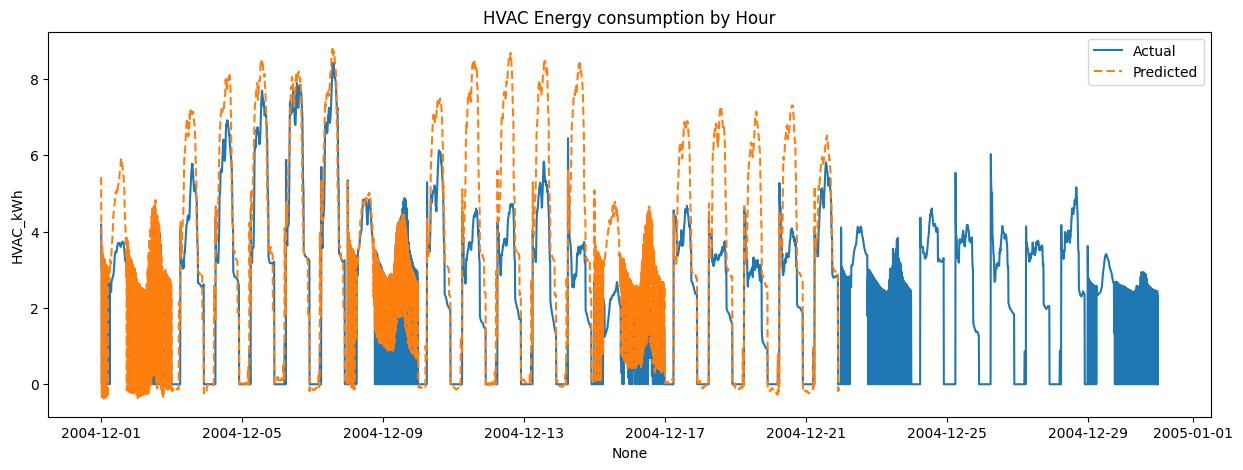

ValueError: Input contains NaN.

In [37]:
pred_df_hybrid_lags = hvac_data[(hvac_data.index.month > 11) & (hvac_data.index.month <= 12)]
pred_df_hybrid_lags['Predictions'] = y_pred_combined_lags
plt.figure(figsize=(15, 5))
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['HVAC_kWh'], label='Actual')
sns.lineplot(x=pred_df_hybrid_lags.index, y=pred_df_hybrid_lags['Predictions'], label='Predicted', dashes=(4,2))
plt.title('HVAC Energy consumption by Hour')
plt.legend()
plt.show()
compute_metrics(pred_df_hybrid_lags['HVAC_kWh'], pred_df_hybrid_lags['Predictions'])